# **Sistemi Lineari: Metodi iterativi**
Consideriamo un sistema lineare nella forma

$$\mathbf{A}\mathbf{x}=\mathbf{b},$$

dove $\mathbf{A}\in\mathbb{R}^{n\times n}$ e $\mathbf{b}\in\mathbb{R}^{n}$ sono noti, mentre $\mathbf{x}\in\mathbb{R}^{n}$ è il vettore incognito.


I medoti di Jacobi, Gauss-Seidel, Richardson, e del gradiente (eccezione fatta per il metodo del gradiente precondizionato) sono accomunati dallo schema iterativo

$$
  \mathbf{x}^{k+1} = \mathbf{B}^k \mathbf{x}^k + \mathbf{g},
$$

con $\mathbf{B}^k = \mathbf{I} - \alpha_k\mathbf{P}^{-1}\mathbf{A}$ e $\mathbf{g} = \mathbf{P}^{-1}\mathbf{b}$.

Segue:

$$
  \mathbf{x}^{k+1} = (\mathbf{I} - \alpha_k\mathbf{P}^{-1}\mathbf{A})\mathbf{x}^k + \mathbf{P}^{-1}\mathbf{b}, \tag{1}
$$

quest'ultima equazione, per una nuova prospettiva, può essere riscritta come

$$
  \mathbf{x}^{k+1} = \mathbf{x}^k + \mathbf{P}^{-1}\mathbf{r}^k,
$$

dove $\mathbf{r}^k$ è il residuo, $\mathbf{r}^k = \mathbf{b}-\mathbf{A}\mathbf{x}^k$.

</br>

**Metodo di Jacobi**: $\mathbf{P} = \text{diag}(\mathbf{A})$, $\alpha_k = 1$.

**Metodo di Gauss-Seidel**: $\mathbf{P} = \text{tril}(\mathbf{A})$, $\alpha_k = 1$.

**Metodo di Richardson stazionario**: $\mathbf{P}$ in base al precondizionatore desiderato, $\alpha_k = \alpha$.

**Metodo del gradiente**: $\mathbf{P}$ in base al precondizionatore desiderato, $\alpha_k = \frac{(\mathbf{d}^k)^T\mathbf{r}^k}{(\mathbf{d}^k)^T\mathbf{A}\mathbf{r}^k}$.


</br></br>

**Nota**: I metodi di Jacobi e Gauss-Seidel vengono tipicamente presentati attraverso la divisione della matrice $\mathbf{A} = \mathbf{D} - \mathbf{E} - \mathbf{F}$, dove $\mathbf{D}$ è la diagonale di $\mathbf{A}$, $-\mathbf{E}$ la triangolare inferiore escludendo la diagonale, $-\mathbf{F}$ la triangolare superiore escludendo la diagonale.  
Lo schema iterativo di Jacobi può essere scritto come
$$
  \mathbf{D}\mathbf{x}^{k+1} = (\mathbf{D}-\mathbf{A})\mathbf{x}^k + \mathbf{b},
$$
ossia
\begin{equation*}
\begin{aligned}
  \mathbf{x}^{k+1} &= \mathbf{D}^{-1}(\mathbf{D}-\mathbf{A})\mathbf{x}^k + \mathbf{D}^{-1}\mathbf{b},\\
   &= \mathbf{D}^{-1}(\mathbf{E}+\mathbf{F})\mathbf{x}^k + \mathbf{D}^{-1}\mathbf{b},
\end{aligned}
\end{equation*}
mentre lo schema di Gauss-Seidel può essere scritto come
$$
  (\mathbf{D} - \mathbf{E})\mathbf{x}^{k+1} = \mathbf{F}\mathbf{x}^k + \mathbf{b},
$$
ossia
$$
  \mathbf{x}^{k+1} = (\mathbf{D} - \mathbf{E})^{-1}\mathbf{F}\mathbf{x}^k + (\mathbf{D} - \mathbf{E})^{-1}\mathbf{b}.
$$


## Parte 1 - Implementazione

In [49]:
# import librerie e funzioni
import numpy as np
import scipy.linalg
# funzione per la risoluzione di sistemi triangolari
from scipy.linalg import solve_triangular
# funzione per gli autovalori
from scipy.linalg import eigvals
from scipy.linalg import eigvalsh


<mark>**Esercizio 1**</mark></br>
Scrivere una function chiamata *jacobi_bg* che, dati $\mathbf{A}$ e $\mathbf{b}$, restituisce la matrice d'iterazione $\mathbf{B}$ ed il vettore di shifting $\mathbf{g}$ associati al metodo di Jacobi. Scrivere quindi una seconda funzione, *gauss_seidel_bg*, che faccia la stessa cosa ma per il metodo di Gauss-Seidel.

Hint: per Jacobi, $\mathbf{P}^{-1}$ è nota in forma chiusa. Per Gauss-Seidel sfruttate la funzione *solve_triangular* del pacchetto *scipy.linalg*.

In [50]:
# Jacobi
def jacobi_bg(A, b=None):
    """
    Metodi di Jacobi
    Input:
    A: matrice quadrata
    b: termine noto (facoltativo)
    Output:
    B: matrice di iterazione di Jacobi
    g: vettore di shifting di Jacobi (se abbiamo come input b)
    """

    # Definisco P^-1, che è possibile dato che P è una matrice diagonal
    P_inv = np.diag(1.0/np.diag(A))
    # Costruisco la matrice di iterazione
    B=np.eye(A.shape[0])-P_inv@A
    if (b is None):
        return B
    else:
        g=P_inv@b
        return B, g

In [51]:
# Gauss-Seidel
def gauss_seidel_bg(A, b=None):
    """
    Metodi di Gauss-Seidel
    Input:
    A: matrice quadrata
    b: termine noto (facoltativo)
    Output:
    B: matrice di iterazione di Gauss-Seidel
    g: vettore di shifting di Gauss-Seidel (se abbiamo come input b)
    """
    #calcolo la matrice P

    P=np.tril(A)
    #calcolo P^-1@A
    P_inv_A=solve_triangular(P,A,lower=True)
    #calcolo B
    B=np.eye(A.shape[0]) - P_inv_A
    if (b is None):
        return B
    else:
        g=solve_triangular(P,b,lower=True)
        return B, g

<mark>**Esercizio 2**</mark></br>
Scrivere una function chiamata *iterative_solve* che, dati

- $\mathbf{A}$ matrice del sistema
- $\mathbf{b}$ termine noto
- $\mathbf{x}_{0}$ guess iniziale
- $\mathbf{B}$ matrice di iterazione
- $\mathbf{g}$ vettore di shifting

approssimi la soluzione $\mathbf{x}$ con il metodo iterativo corrispondente. La function dovrà accettare anche altri due parametri: **nmax**, cioè il numero massimo di iterazioni, **rtoll**, la tolleranza relativa richiesta. Il particolare, il metodo iterativo va arrestato se

$$\frac{\|\mathbf{r}^{(k)}\|}{\|\mathbf{b}\|}<\textbf{rtoll},$$

dove $\mathbf{r}^{(k)}:= \mathbf{b} - \mathbf{A}\mathbf{x}^{(k)}$ è il residuo alla *k*-esima iterazione.

*Nota*: costruite la function di modo che, in output, essa restituisca la lista delle iterate $[\mathbf{x}_{0},\dots,\mathbf{x}_{N}]$.

In [52]:
#questo è quello che ho fatto io 

def iterative_solve(A, b, x0, B, g, nmax, rtoll):
    """
    Metodo di risoluzione utilizzando i metodi iterativi

    Input:
    A: matrice quadrata
    b: termine noto
    x0: vettore di innesco
    B: matrice di iterazione
    g: vettore di shifting
    nmax: numero massimo di iterazioni
    rtoll: tolleranza relativa richiesta

    Output:
    xiter: lista contenente tutte le iterate
    """

    # inizializzazione
    xiter=[]
    i=0
    xold=x0

    # passo iterativo
    while (i<=nmax):
        i=i+1
        xnew=B@xold+g
        # carico la lista xiter
        xiter.append(xnew)
        # residuo di xnew
        r=b-A@xnew
        # test di arresto
        if (np.linalg.norm(r)/np.linalg.norm(b)<rtoll):
            break   
        # aggiorno
        xnew=xold

       
    xiter=np.array(xiter)
    return xiter 

In [53]:
#questo è quello che ha nfatto lui


def iterative_solve(A, b, x0, B, g, nmax, rtoll):
    """
    Metodo di risoluzione utilizzando i metodi iterativi

    Input:
    A: matrice quadrata
    b: termine noto
    x0: vettore di innesco
    B: matrice di iterazione
    g: vettore di shifting
    nmax: numero massimo di iterazioni
    rtoll: tolleranza relativa richiesta

    Output:
    xiter: lista contenente tutte le iterate
    """

    # inizializzazione
    bnorm=np.linalg.norm(b)
    xiter=[x0]
    n=0
    err = 1+rtoll
    xold=x0
    while (n<nmax and err>rtoll):
        xnew=B@xold+g
        xiter.append(xnew)
        r=b-A@xnew
        err=np.linalg.norm(r)/bnorm
        xold=xnew
        n=n+1
    return xiter

    

## Parte 2 - Sperimentazione

<mark>**Esercizio 3**</mark></br>
Si consideri la seguente matrice quadrata


$$\mathbf{A}=\left[\begin{array}{cccccc}
1 & 1 & 1 & 1 & \dots & 1\\
R_{1} & - R_{2} & 0 & 0 & \dots & 0\\
0 & R_{1} & - R_{2} & 0 &  \dots & 0\\
\dots & 0 & \ddots & \ddots &   & \dots\\
\dots & \dots &  & \ddots &  \ddots & \dots\\
0 & 0 & 0 & \dots & R_{1} & - R_{2} \\
\end{array}\right]$$


di dimensione $n=100$, avendo posto $R_{1}=1$ ed $R_{2}=2$.
</br></br>

a) Assemblare le matrici di iterazione $B_{\text{J}}$ e $B_{\text{GS}}$ dei metodi di Jacobi e Gauss-Seidel, quindi calcolarne i rispettivi raggi spettrali. La condizione
necessaria e sufficiente per la convergenza del metodo iterativo è soddisfatta in entrambi i casi?

*Hint: Usare la function $\texttt{eigvals}$ di $\texttt{scipy.linalg}$ per il calcolo degli autovalori.*
</br></br>

b) Sia $\mathbf{b}=[2,1,1,\dots,1]^{\top}\in\mathbb{R}^{n}$. Approssimare la soluzione del sistema lineare $\mathbf{A}\mathbf{x}=\mathbf{b}$ con il metodo di Jacobi. Si pongano $$\mathbf{x}_{0}=[0,\dots,0]^{\top},\quad\texttt{rtoll}=10^{-6},\quad\texttt{nmax}=1000.$$ Il metodo converge? Se sì, in quante iterazioni?

In [54]:
# Costruzione della matrice A
n = 100
R1, R2 = 1, 2

A = -R2*np.diag(np.ones(n))
A[0, :] = 1
A = A + R1*np.diag(np.ones(n-1), -1)

In [55]:
# a) Raggi spettrali


# calcolo le matrici di iterazione di Jacobi e GS
B_j=jacobi_bg(A)
B_gs=gauss_seidel_bg(A)
# calcolo i raggi spettrali
rho_j=np.max(np.abs(eigvals(B_j)))
rho_gs=np.max(np.abs(eigvals(B_gs)))

# Stampo i raggi spettrali di Jacobi e Gauss-Seidel
print(rho_j)
print(rho_gs)

0.7071067811865468
0.9999999999999998


In [56]:
# b)
#  termine noto
b=np.ones(n)
b[0]=2
# Guess iniziale
x0 = np.zeros(n)

# Applicazione di Jacobi
B_j, g_j = jacobi_bg(A,b)

# Numero di iterazioni
xiter=iterative_solve(A,b,x0,B_j,g_j,1000,1e-6)
print(len(xiter)-1)

47


<mark>**Esercizio 4**</mark></br>
Si considerino la matrice e il termine noto
</br>
</br>
\begin{equation*}
\mathbf{A}=\left[\begin{array}{rrrrrrr}
9 & -3 & 1 &  &  & & \\
-3 & 9 & -3 & 1 &  & & \\
1 & -3 & 9 & -3 & 1 & & \\
& 1 & -3 & 9 & -3 & 1 &\\
& & 1 & -3 & 9 & -3 & 1 \\
& & & 1 & -3 & 9 & -3  \\
& & & & 1 & -3 & 9  \\
\end{array}\right],\quad\quad \mathbf{b}=\left[\begin{array}{c}7\\4\\5\\5\\5\\4\\7\end{array}\right].
\end{equation*}
</br>
a) Studiare le caratteristiche della matrice $\mathbf{A}$, stabilendo se sia simmetrica, definita positiva e a dominanza diagonale per righe $^*$.
</br></br>
b) Approssimare la soluzione del sistema lineare $\mathbf{A}\mathbf{x}=\mathbf{b}$ con i metodi di Jacobi e di Gauss-Seidel, utilizzando il vettore nullo come guess iniziale. Si pongano $$\texttt{rtoll}=10^{-6} \quad \text{and} \quad \texttt{nmax}=1000.$$ 
Confrontare il numero
di iterazioni necessarie per arrivare a convergenza per i due metodi e commentare i risultati
ottenuti.
</br>
</br>
La soluzione esatta del sistema lineare è $\mathbf{x}=[1, 1, 1, 1, 1, 1, 1]^T$.
</br>
</br>
</br>
</br>
$^*$*Hint: sfruttare la function $\texttt{eigvalsh}$ del pacchetto $\texttt{scipy.linalg}$, che restituisce gli autovalori per una matrice simmetrica o Hermitiana.*

In [57]:
# a) Assemblaggio di A e check delle proprietà


n = 7
A = -3 * np.diag(np.ones(n-1), 1) + np.diag(np.ones(n-2), 2)
A = 9 * np.diag(np.ones(n)) + A + A.T
#per vedere se la matrice è definita positica calcolo il minimo autovalore
print(np.min(eigvalsh(A)))

4.904226454981305


In [58]:
# b) Applicazione dei metodi e confronto
b = np.array([7, 4, 5, 5, 5, 4, 7])
# guess iniziale
x0 = np.zeros(n)
# risolvo Jacobi e Guass-Seidel
B_j, g_j = jacobi_bg(A,b)
B_gs, g_gs = gauss_seidel_bg(A,b)

xj = iterative_solve(A,b,x0,B_j,g_j,1000,1e-6)
xgs = iterative_solve(A,b,x0,B_gs,g_gs,1000,1e-6)

print(xj[-1])
print(xgs[-1])

[1.00000018 0.9999997  1.00000039 0.99999959 1.00000039 0.9999997
 1.00000018]
[0.99999958 1.00000003 1.00000032 1.00000019 1.00000001 0.99999997
 0.99999999]


In [59]:
# Tabella che mi stampa la convergenza e il numero di iterazioni
print("\t\t\tJacobi\tGauss-Seidel\n" + "-"*44)
print("Convergenza:\t\t%s\t%s" % (len(xj)-1 < 1000, len(xgs)-1 < 1000))
print("Numero di iterazioni:\t%d\t%d" % (len(xj)-1, len(xgs)-1))

			Jacobi	Gauss-Seidel
--------------------------------------------
Convergenza:		True	True
Numero di iterazioni:	49	12


## Parte 3 - Metodi pre-implementati: gradiente e gradiente coniugato

<mark>**Esercizio 5**</mark></br>
La function $\texttt{cg}$ del pacchetto $\texttt{scipy.sparse.linalg}$ implementa il metodo del gradiente coniugato. Viceversa, la function $\texttt{gdescent}$, disponibile nello script $\texttt{utils.py}$, implementa il metodo del gradiente.
</br></br>
Una volta appurato che entrambi i metodi sono applicabili al problema dell'esercizio 5
</br></br>
a) Approssimare la soluzione del sistema con i metodi del gradiente e del gradiente coniugato. Si utilizzino gli stessi iperparametri usati all'es. 5 (guess iniziale, tolleranza relativa, numero massimo di iterazioni). I metodi convergono? Che soluzione si ottiene?
</br></br>
b) Nei due casi, quante iterazioni ci sono volute? *Hint: per $\texttt{cg}$, sfruttate l'input opzionale $\texttt{callback}$*!

In [115]:
from utils import gdescent
xg = gdescent(A, b, x0, nmax=10000, rtoll=1e-5)

print("Soluzione approssimata (Gradient descent):")
print(xg[-1])

# numero iterazioni metodo del gradiente
print("Numero di iterazioni effettuate: %d" % (len(xg)-1))

Soluzione approssimata (Gradient descent):
[0.09385413 0.12066972 0.14860288 0.16089284 0.1675966  0.1675966
 0.16089284 0.14860288 0.12066972 0.09385413]
Numero di iterazioni effettuate: 24


In [61]:
from scipy.sparse.linalg import cg

# Definisco la lista con la guess iniziale
xcg = [x0]
# chiamo la function cg del gradiente coniugato
x, info = cg(A, b, x0, rtol=1e-6, maxiter=1000,
             callback=lambda xk: xcg.append(xk+0.0))

print("\nSoluzione approssimata (CG):")
print(x)
print("Numero di iterazioni effettuate: %d" % (len(xcg)-1))


Soluzione approssimata (CG):
[1. 1. 1. 1. 1. 1. 1.]
Numero di iterazioni effettuate: 4


## Esercizi per casa

<mark>**Esercizio 6**</mark></br>
Scrivete le seguenti function a valori booleani (vero o falso):

- **sym** che, data $\mathbf{A}$, restituisce $\texttt{True}$ se e solo se $\mathbf{A}$ è simmetrica;

- **sdp** che, data $\mathbf{A}$, restituisce $\texttt{True}$ se e solo se $\mathbf{A}$ è simmetrica definita positiva;

- **rowdom** che, data $\mathbf{A}$, restituisce $\texttt{True}$ se e solo se $\mathbf{A}$ è a dominanza diagonale per righe.

In [89]:

A=np.array([[1,2],[3,4]])
B=np.array([[10,2,3],
            [2,10,5],
            [3,5,10]])
C=np.diag(np.ones(5))
D=np.diag(np.zeros(10))
print(B)

[[10  2  3]
 [ 2 10  5]
 [ 3  5 10]]


In [91]:

#primo metodo che mi è venuto in mente
def sym(A):
 for i in range(A.shape[0]):
  for j in range(i):
    if(A[i][j]!=A[j,i]):
     return print("matrice non è simmetrica")
 return print("matrice è simmetrica")


#secondo metodo, pensando che la matrice se trasposta è uguale a se stess

def sym2(A):
 if (A==A.T).all():
  return print("matrice simmetrica")
 else:
  return print("matrice non simmetrica")


# allora definita positiva se tutti autovalori positivi
def sdp(A):
 if (np.min(eigvalsh(A))>0):
  return print("matrice definita positiva")
 elif (np.max(eigvalsh(A))<0):
  return print("matrice definita negativa")
 else:
  return print("matrice indefita")


#dominanza per righe nella riga i-esima se abs del termine sulla diagonale deve essere maggiore della somama dei moduli dei termini non sulla diagonale 
def rowdom(A):
 for i in range(A.shape[0]):
  s=0
  for j in range (A.shape[0]):
   s=s+abs(A[i][j])
   
  if (s-abs(A[i][i])>abs(A[i][i])):
   return print("false")

 return print("dominanza diagonale per righe")
rowdom(A)
rowdom(B)


false
dominanza diagonale per righe


<mark>**Esercizio 7**</mark></br>
Si considerino la matrice pentadiagonale ed il termine noto
\begin{equation*}
\mathbf{A}=\left[\begin{array}{rrrrrrr}
5 & -1 & -1 &  &  & & \\
-1 & 5 & -1 & -1 &  & & \\
-1 & -1 & 5 & -1 & -1 & & \\
& \ddots  & \ddots & \ddots & \ddots & \ddots  &\\
& & -1 & -1 & 5 & -1 & -1 \\
& & &  -1 & -1 & 5 & -1 \\
& & & & -1 & -1 & 5 \\
\end{array}\right],\quad\quad \mathbf{b}=\left[\begin{array}{c}0.2\\0.2\\0.2\\\vdots\\0.2\\0.2\\0.2\end{array}\right].
\end{equation*}
</br>
a) La matrice $\mathbf{A}$ è simmetrica definitiva positiva?
</br></br>
b) Approssimare la soluzione del sistema lineare con i metodi di Jacobi, Gauss-Seidel, Gradiente e Gradiente Coniugato (si utilizzi il vettore nullo come guess iniziale, $10^{-5}$ come tolleranza relativa, $1000$ come numero massimo di iterazioni).
</br></br>
c) Plottare l'andamento del residuo relativo $\|\mathbf{r}^{(k)}\|/\|\mathbf{b}\|$ in funzione delle iterate $k$, mettendo così a paragone i quattro metodi.


In [96]:
# a) Assemblaggio matrice e check proprietà
n=10
d=np.ones(n)
A=np.diag(d*5)+np.diag(-d[:-2],-2)+np.diag(-d[:-1],-1)+np.diag(-d[:-1],1)+np.diag(-d[:-2],2)
b=0.2*np.ones(n)
x0=np.zeros(n)
from scipy.sparse.linalg import cg
print(A)
sdp(A)
sym(A)
rowdom(A)

[[ 5. -1. -1.  0.  0.  0.  0.  0.  0.  0.]
 [-1.  5. -1. -1.  0.  0.  0.  0.  0.  0.]
 [-1. -1.  5. -1. -1.  0.  0.  0.  0.  0.]
 [ 0. -1. -1.  5. -1. -1.  0.  0.  0.  0.]
 [ 0.  0. -1. -1.  5. -1. -1.  0.  0.  0.]
 [ 0.  0.  0. -1. -1.  5. -1. -1.  0.  0.]
 [ 0.  0.  0.  0. -1. -1.  5. -1. -1.  0.]
 [ 0.  0.  0.  0.  0. -1. -1.  5. -1. -1.]
 [ 0.  0.  0.  0.  0.  0. -1. -1.  5. -1.]
 [ 0.  0.  0.  0.  0.  0.  0. -1. -1.  5.]]
matrice definita positiva
matrice è simmetrica
dominanza diagonale per righe


In [ ]:
# b) Applicazione dei metodi iterativi


# Gradiente

x_G=gdescent(A, b, x0, nmax=10000, rtoll=1e-5)
x_G=np.array(x_G)
print(x_G[-1])
# Gradiente coniugato (sfruttiamo il callback per salvare le iterate: ci servirà dopo)
x_Gc=[]
x_finale=cg(A,b,x0,rtol=1e-5,maxiter=1000, callback= lambda xk: x_Gc.append(xk+0.0))[0]
print(x_Gc[-1])
# Jacobi
B_j, g_j=jacobi_bg(A,b)
x_j=iterative_solve(A,b,x0,B_j, g_j,1000,rtoll=1e-5)
print(x_j[-1])
# Gauss-Seidel
B_gs, g_gs=gauss_seidel_bg(A,b)
x_gs=iterative_solve(A,b,x0,B_gs, g_gs,1000,rtoll=1e-5)
print(x_gs[-1])

[0.09385413 0.12066972 0.14860288 0.16089284 0.1675966  0.1675966
 0.16089284 0.14860288 0.12066972 0.09385413]
[0.09385475 0.12067039 0.14860335 0.16089385 0.16759777 0.16759777
 0.16089385 0.14860335 0.12067039 0.09385475]
[0.09385421 0.12066957 0.14860223 0.16089254 0.16759634 0.16759634
 0.16089254 0.14860223 0.12066957 0.09385421]
[0.09385399 0.12066945 0.14860227 0.16089281 0.16759683 0.16759699
 0.16089326 0.14860294 0.12067014 0.09385462]


In [ ]:
# c) Calcolo dei residui e plot
bnorm = np.linalg.norm(b)  
r_G = [] 
for i in range(len(x_G)):
    r_Ga=A@x_G[i]-b
    r_Gr=np.linalg.norm(r_Ga) / bnorm
    r_G.append(r_Gr)
rgs = [np.linalg.norm(A @ xk- b) / bnorm for xk in x_gs]
rgd = [np.linalg.norm(A @ xk- b) / bnorm for xk in xgd]
rcg = [np.linalg.norm(A @ xk- b) / bnorm for xk in xcg]

[np.float64(1.0),
 np.float64(0.4999999999999999),
 np.float64(0.16848104982335987),
 np.float64(0.08931401680277723),
 np.float64(0.06188977564630642),
 np.float64(0.036436256600708976),
 np.float64(0.02534914690030361),
 np.float64(0.014933620204397324),
 np.float64(0.010391693733198837),
 np.float64(0.006123129045641859),
 np.float64(0.004261112264827468),
 np.float64(0.002510940620385114),
 np.float64(0.0017474097028328678),
 np.float64(0.0010297133449422504),
 np.float64(0.000716600869772332),
 np.float64(0.00042228089366347783),
 np.float64(0.0002938754107709662),
 np.float64(0.00017317616587929238),
 np.float64(0.00012051752156794276),
 np.float64(7.10191221279393e-05),
 np.float64(4.942394978122392e-05),
 np.float64(2.9124778444634126e-05),
 np.float64(2.0268649117488845e-05),
 np.float64(1.1944005851366175e-05),
 np.float64(8.312127360611165e-06)]

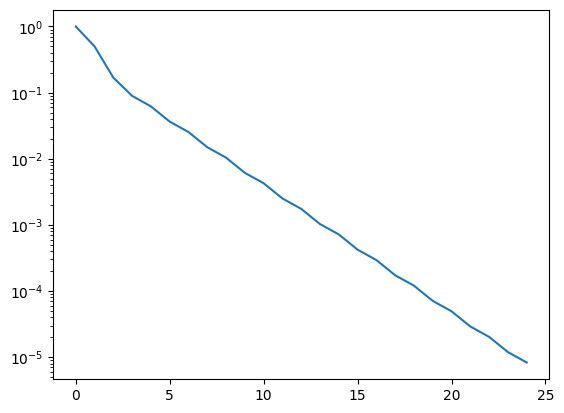

In [132]:
import matplotlib.pyplot as plt
plt.semilogy(range(len(x_G)),r_G)
# Plot in scala logaritmica sulle y
